# **Task 1: Use NLP Techniques to Analyze a Collection of Texts**

## **Project Title: NLP-Based Topic Modeling of Consumer Complaints**

### **Notebook 4: Training and Evaluating the Final Topic Models**

#### **Introduction**

With the optimal number of topics (k) identified in the previous notebook, this final step focuses on training, evaluating, and interpreting the topic models. Using LDA, NMF, and BERTopic, we extract meaningful themes from consumer complaints and assess their effectiveness using coherence scores and visualization techniques.

## **1. Import Necessary Libraries**

In [1]:
# Basic
import pandas as pd
import numpy as np
import spacy
import nltk

# Modeling
from gensim.models.ldamodel import LdaModel
from gensim.corpora.dictionary import Dictionary
from sklearn.decomposition import LatentDirichletAllocation, NMF
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

# Evaluation and Visualization
from gensim.models import CoherenceModel
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

## **2. Load Preprocessed and  Vectorized Data**

In [2]:
# Define the file path
file_path = "/Users/achshahrm/Library/Mobile Documents/com~apple~CloudDocs/Documents/IU International/Sem 05/Project Data Analysis/project_final/data/preprocessed_complaints.csv"

# Load the data into a DataFrame
data_preprocessed = pd.read_csv(file_path)

# Display the first few rows of the DataFrame
data_preprocessed.head()

,complaints_text
0,purchase order day shipping amount receive pro...
1,forward message date tue subject please invest...
2,forward message cc send friday pdt subject fin...
3,payment history miss credit report specialize ...
4,payment history miss credit report make mistak...


In [3]:
# Load BoW and TF-IDF feature names
feature_names_bow = np.loadtxt("/Users/achshahrm/Library/Mobile Documents/com~apple~CloudDocs/Documents/IU International/Sem 05/Project Data Analysis/project_final/results/vectorized/feature_names_bow.txt", dtype=str)
feature_names_tfidf = np.loadtxt("/Users/achshahrm/Library/Mobile Documents/com~apple~CloudDocs/Documents/IU International/Sem 05/Project Data Analysis/project_final/results/vectorized/feature_names_tfidf.txt", dtype=str)

# Define the file path
bow_path = "/Users/achshahrm/Library/Mobile Documents/com~apple~CloudDocs/Documents/IU International/Sem 05/Project Data Analysis/project_final/results/vectorized/bow_representation.csv"
tfidf_path = "/Users/achshahrm/Library/Mobile Documents/com~apple~CloudDocs/Documents/IU International/Sem 05/Project Data Analysis/project/results/vectorized/tfidf_representation.csv"

# Load the data into a DataFrame
bow_df = pd.read_csv(bow_path)
tfidf_df = pd.read_csv(tfidf_path)

In [4]:
# Display the first few rows of the BoW DataFrame
bow_df.head()

,aa,aadvantage,aag,aargon,abandon,abide,ability,able,abroad,abruptly,...,yo,york,young,yr,zelle,zero,zip,zombie,zone,zwicker
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# Display the first few rows of the TF-IDF DataFrame
tfidf_df.head()

,aa,aadvantage,aag,aargon,abandon,abide,ability,able,abroad,abruptly,...,yo,york,young,yr,zelle,zero,zip,zombie,zone,zwicker
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0968,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.105765,0.0,0.0,...,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.117352,0.0,0.0,...,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## **3. LDA Using Gensim**

### With BoW Method

In [6]:
# Create Dictionary and Corpus for BoW
bow_dictionary = Dictionary(data_preprocessed['complaints_text'].str.split())
bow_corpus = [bow_dictionary.doc2bow(text.split()) for text in data_preprocessed['complaints_text']]

# Train Optimized LDA Model with BoW
lda_bow = LdaModel(
    corpus=bow_corpus, 
    id2word=bow_dictionary, 
    num_topics=20,  
    random_state=42, 
    passes=10,  
    alpha='auto',  
    eta='auto'  
)

### With TF-IDF Method

In [7]:
# Create Dictionary and Corpus for TF-IDF
tfidf_dictionary = Dictionary(data_preprocessed['complaints_text'].str.split())
tfidf_corpus = [tfidf_dictionary.doc2bow(text.split()) for text in data_preprocessed['complaints_text']]

# Train LDA Model with TF-IDF
lda_tfidf = LdaModel(
    corpus=tfidf_corpus, 
    id2word=tfidf_dictionary, 
    num_topics=20,  
    random_state=42, 
    passes=10,  
    alpha='auto',  
    eta='auto'
)

### Evaluate Topic Coherence

In [8]:
# Evaluate Coherence for BoW
coherence_model_bow = CoherenceModel(model=lda_bow, texts=data_preprocessed['complaints_text'].str.split(), dictionary=bow_dictionary, coherence='c_v')
coherence_lda_bow = coherence_model_bow.get_coherence()
print(f'LDA with BoW Coherence Score: {coherence_lda_bow}')

# Evaluate Coherence for TF-IDF
coherence_model_tfidf = CoherenceModel(model=lda_tfidf, texts=data_preprocessed['complaints_text'].str.split(), dictionary=tfidf_dictionary, coherence='c_v')
coherence_lda_tfidf = coherence_model_tfidf.get_coherence()
print(f'LDA with TF-IDF Coherence Score: {coherence_lda_tfidf}')

LDA with BoW Coherence Score: 0.5100809957182767
LDA with TF-IDF Coherence Score: 0.5100809957182767


### Evaluate pyLDAvis Visualization

In [9]:
# Define the save path
save_path = "/Users/achshahrm/Library/Mobile Documents/com~apple~CloudDocs/Documents/IU International/Sem 05/Project Data Analysis/project_final/results/plots/lda_bow_pyLDAvis.html"

# Visualize LDA with BoW
pyLDAvis.enable_notebook()
lda_bow_vis = gensimvis.prepare(lda_bow, bow_corpus, bow_dictionary)

# Save visualization in the specified directory
pyLDAvis.save_html(lda_bow_vis, save_path)

# Display the visualization
pyLDAvis.display(lda_bow_vis)

This interactive plot provides insights into the topic modeling results from the LDA model using BoW. Below are the key takeaways:

**Topic Interpretations:**

- Topic 1: Focuses on communication and customer interactions, with words like "call, tell, say, would, time, ask, phone, speak". This topic likely relates to customer service complaints or inquiries.

- Topic 2: Highlights response and complaint processing, with words like "receive, request, email, send, provide, letter, response". This topic likely pertains to customers seeking responses from financial institutions.

- Topic 3: Covers payment-related issues, featuring words like "payment, credit, account, pay, late, balance, due, fee". This topic is associated with billing, overdue payments, and account balances.

- Topic 4: Captures credit report disputes and issues with credit bureaus, including words like "report, credit, dispute, bureau, remove, file, inaccurate". This topic relates to customers raising concerns about incorrect credit reporting.

- Topic 5: Addresses mortgage and home loan-related concerns, with words like "loan, mortgage, payment, home, escrow, interest, lender". This topic likely pertains to mortgage servicing, refinancing, or loan disputes.

- Topic 6: Highlights banking and financial institution complaints, with words like "Wells, Fargo, company, complaint, customer, service, state". This topic may focus on customer dissatisfaction with specific financial institutions.

- Topic 7: Covers debt collection and agency-related complaints, featuring words like "debt, collection, company, owe, send, receive, letter". This topic relates to issues with debt recovery and aggressive collection practices.

- Topic 8: Discusses banking transactions and fund transfers, with words like "account, bank, check, money, fund, deposit, transfer". This topic likely involves complaints about bank account management, deposits, or unauthorized transactions.

- Topic 9: Focuses on legal issues and compliance, featuring words like "debt, act, law, violation, court, legal, compliance". This topic relates to lawsuits, legal disputes, and financial regulation compliance.

- Topic 10: Highlights fraud and identity theft, with words like "card, bank, fraud, charge, credit, fraudulent, theft". This topic relates to customers reporting fraudulent transactions and identity misuse.

- Topic 11: Covers credit status and account closure, featuring words like "account, date, balance, open, status, close, creditor". This topic relates to credit account updates, closures, and disputes with creditors.

- Topic 12: Discusses identity verification and security concerns, with words like "account, number, name, remove, verify, social, security". This topic relates to concerns over personal data and identity theft prevention.

- Topic 13: Focuses on consumer rights and privacy, featuring words like "consumer, report, information, block, agency, identity, subsection". This topic relates to financial data security and rights under consumer protection laws.

- Topic 14: Covers refunds and chargeback disputes, with words like "capital, card, charge, dispute, refund, transaction, merchant". This topic is associated with complaints about refunds, returned transactions, and merchant disputes.

- Topic 15: Highlights legal compliance and regulatory concerns, featuring words like "claim, report, plaintiff, compliance, complaint, document". This topic relates to financial institutions' legal obligations and regulatory disputes.

- Topic 16: Discusses credit inquiries and security freezes, with words like "credit, inquiry, report, equifax, freeze, remove, alert". This topic pertains to unauthorized credit checks and credit security measures.

- Topic 17: Covers auto and student loan issues, with words like "loan, car, vehicle, student, auto, finance, lender". This topic relates to financing for cars and education, as well as loan repayment issues.

- Topic 18: Focuses on rental and lease agreements, featuring words like "purchase, express, store, lease, rent, repair, program". This topic is related to rental disputes, lease agreements, and property management complaints.

- Topic 19: Discusses government and federal financial matters, with words like "navient, federal, record, state, recall, complaint". This topic likely relates to government-backed financial programs, such as student loans or federal assistance.

- Topic 20: Appears to be an outlier topic with uncommon terms like "acknowledgment, Wells Fargo, Robinhood, downpayment, retention, prestige". This topic may relate to niche financial services or sporadic issues not covered by other topics.

**General Observations:**

- Topics like fraud, mortgage, debt collection, and legal disputes are well-defined.

- Certain topics, like those related to credit reports and disputes, have some overlapping words, which may suggest semantic similarity.

- Topics 19 and 20 have smaller circles, meaning they account for a small fraction of the dataset.

- Most topics are well-separated, indicating good topic coherence.

In [10]:
# Define the save path
save_path = "/Users/achshahrm/Library/Mobile Documents/com~apple~CloudDocs/Documents/IU International/Sem 05/Project Data Analysis/project_final/results/plots/lda_tfidf_pyLDAvis.html"

# Visualize LDA with TF-IDF
pyLDAvis.enable_notebook()
lda_tfidf_vis = gensimvis.prepare(lda_tfidf, tfidf_corpus, tfidf_dictionary)

# Save visualization
pyLDAvis.save_html(lda_tfidf_vis, save_path)

# Display the visualization
pyLDAvis.display(lda_tfidf_vis)

This interactive plot provides insights into the topic modeling results from the LDA model using TF-IDF. The visualization reveals a similar pattern to the BoW representation. Below are the key takeaways:

**Topic Interpretations:**

- Topic 1: Focuses on communication and customer interactions, with words like "call, tell, say, would, time, ask, phone, speak." This topic likely relates to customer service complaints or inquiries.

- Topic 2: Relates to receiving and processing customer requests, with terms like "receive, request, email, send, provide, response, complaint, contact." This topic pertains to correspondence about financial services.

- Topic 3: Discusses credit card payments and account balances, with words like "payment, credit, account, pay, late, balance, due, fee, charge." This topic is likely about payment issues and overdue balances.

- Topic 4: Concerns credit report discrepancies, featuring words like "report, credit, account, dispute, bureau, remove, file, request." It suggests issues related to credit reporting and corrections.

- Topic 5: Covers mortgage and home loans, with terms like "loan, mortgage, payment, home, pay, insurance, escrow, refinance." This topic relates to mortgage servicing and refinancing concerns.

- Topic 6: Highlights customer dissatisfaction with a particular financial institution, containing words like "wells, fargo, complaint, business, issue, cfpb, customer, company." It suggests grievances against a major financial service provider.

- Topic 7: Deals with debt collection, featuring terms like "debt, collection, company, owe, letter, agency, collect, contact, dispute." This topic revolves around debt recovery practices.

- Topic 8: Discusses banking transactions and account issues, with words like "account, bank, check, money, deposit, transfer, app, hold." This topic pertains to transaction processing and fund availability.

- Topic 9: Concerns legal and regulatory issues, containing words like "debt, act, allege, law, collection, violation, federal, court, compliance." This topic highlights legal complaints and regulatory matters.

- Topic 10: Addresses fraud and identity theft, with terms like "card, bank, fraud, charge, credit, fraudulent, theft, identity." This topic is about unauthorized transactions and fraudulent activities.

- Topic 11: Discusses account status and responsibility, with words like "account, balance, open, status, creditor, responsibility, negative, dispute." This topic relates to account closures and financial obligations.

- Topic 12: Focuses on personal information verification, containing words like "account, number, name, remove, report, social, security, verify, identity." This topic relates to identity verification and security concerns.

- Topic 13: Relates to consumer credit reports and privacy, with terms like "consumer, report, block, agency, identity, theft, company, service." This topic highlights concerns about data security and credit monitoring.

- Topic 14: Concerns refunds and disputes, featuring words like "credit, refund, cancel, transaction, purchase, return, policy, service." This topic pertains to chargebacks and payment reversals.

- Topic 15: Covers regulatory compliance and legal documentation, with words like "claim, report, compliance, complaint, regulatory, fact, proof, ownership." This topic deals with financial service regulations.

- Topic 16: Discusses credit inquiries and security freezes, with words like "credit, inquiry, report, equifax, freeze, remove, alert." This topic pertains to unauthorized credit checks and credit security measures.

- Topic 17: Relates to auto loans and financing, containing words like "loan, car, vehicle, auto, finance, pay, lender, lease, contract." This topic focuses on vehicle-related financing concerns.

- Topic 18: Discusses financial services and special programs, with words like "american, purchase, express, store, fee, lease, program, rental." This topic pertains to specific financial services and promotions.

- Topic 19: Covers government-backed loans and financial disputes, with words like "federal, navy, sba, record, venmo, midland, state, brokerage." This topic involves public financial programs and associated complaints.

- Topic 20: Appears to be an outlier or less significant topic, with words like "acknowledgment, stipulate, robinhood, downpayment, compassionate, entity, increment." This topic might include residual or ambiguous terms.

**Comparison with Bag-of-Words (BoW) Method:**

- Compared to the BoW method, TF-IDF better differentiates between nuanced financial concerns, such as identity verification (Topic 12) and security freezes (Topic 16).

- TF-IDF results in more clearly separated topics, reducing topic overlap seen in BoW.

- Unlike BoW, which favors frequently occurring words, TF-IDF highlights terms that are more informative but appear less often, providing better topic interpretability.

### Evaluate Word Cloud Visualization

In [16]:
# Function to generate a grid of word clouds
def plot_wordclouds_grid(lda_model, num_topics, dictionary, title):
    # Create a grid layout (5 columns x 4 rows for 20 topics)
    fig, axes = plt.subplots(4, 5, figsize=(20, 8))  
    axes = axes.flatten()
    
    # Generate word clouds for each topic
    for topic_idx, ax in enumerate(axes[:num_topics]):
        wordcloud = WordCloud(width=800, height=400, background_color='white')
        topic_terms = dict(lda_model.show_topic(topic_idx, topn=20))
        wordcloud.generate_from_frequencies(topic_terms)
        ax.imshow(wordcloud, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f"Topic {topic_idx}", fontsize=14)
    
    # Turn off unused axes
    for ax in axes[num_topics:]:
        ax.axis('off')
    
    # Add an overall title
    plt.suptitle(title, fontsize=18, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.95]) 
    plt.show()

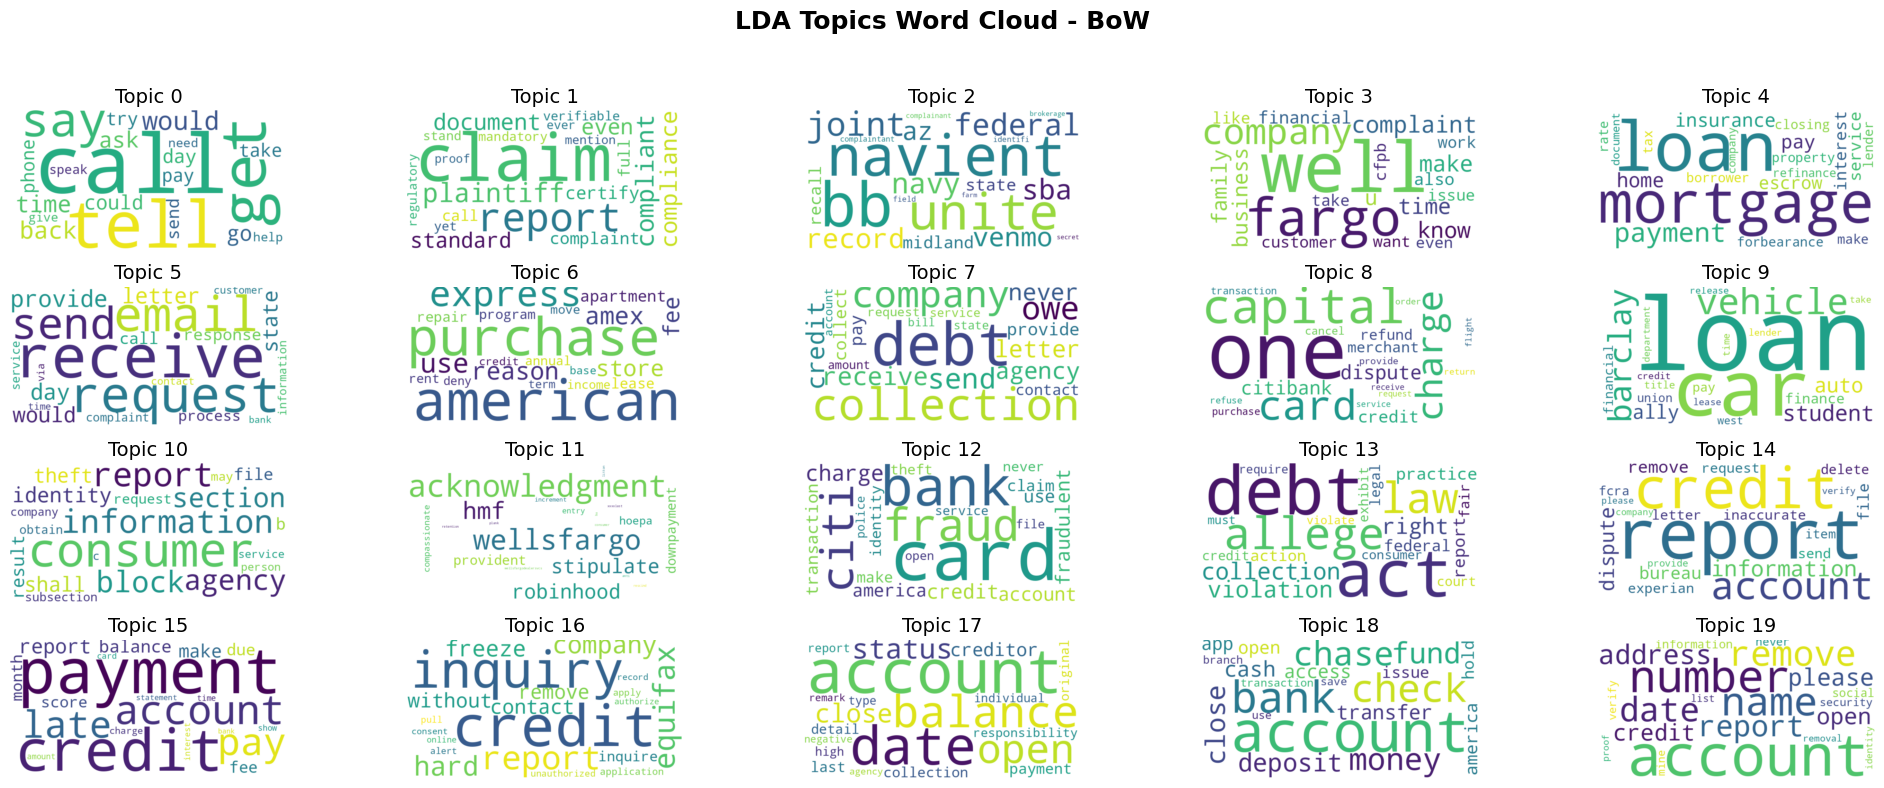

In [17]:
# Generate word clouds for LDA with BoW
plot_wordclouds_grid(lda_bow, lda_bow.num_topics, bow_dictionary, "LDA Topics Word Cloud - BoW")

The word clouds above illustrate the most important terms for each of the 20 topics identified by the LDA model using Bag of Words (BoW). The analysis validates the PyLDAvis interpretations, showing that both methods provide consistent insights into key themes such as customer service issues, debt collection, credit reporting disputes, mortgage concerns, fraud, and regulatory compliance.

One unique observation from the word clouds is the prominence of specific financial institutions and brands (e.g., "Wells Fargo," "Equifax," "Robinhood"), which were less explicitly visible in the interactive PyLDAvis plot. This suggests that certain companies are frequently mentioned in consumer complaints, indicating a potential trend in financial disputes linked to particular institutions. Additionally, the word clouds highlight transaction-related issues like "purchase," "refund," and "merchant," reinforcing concerns about online and retail banking disputes.

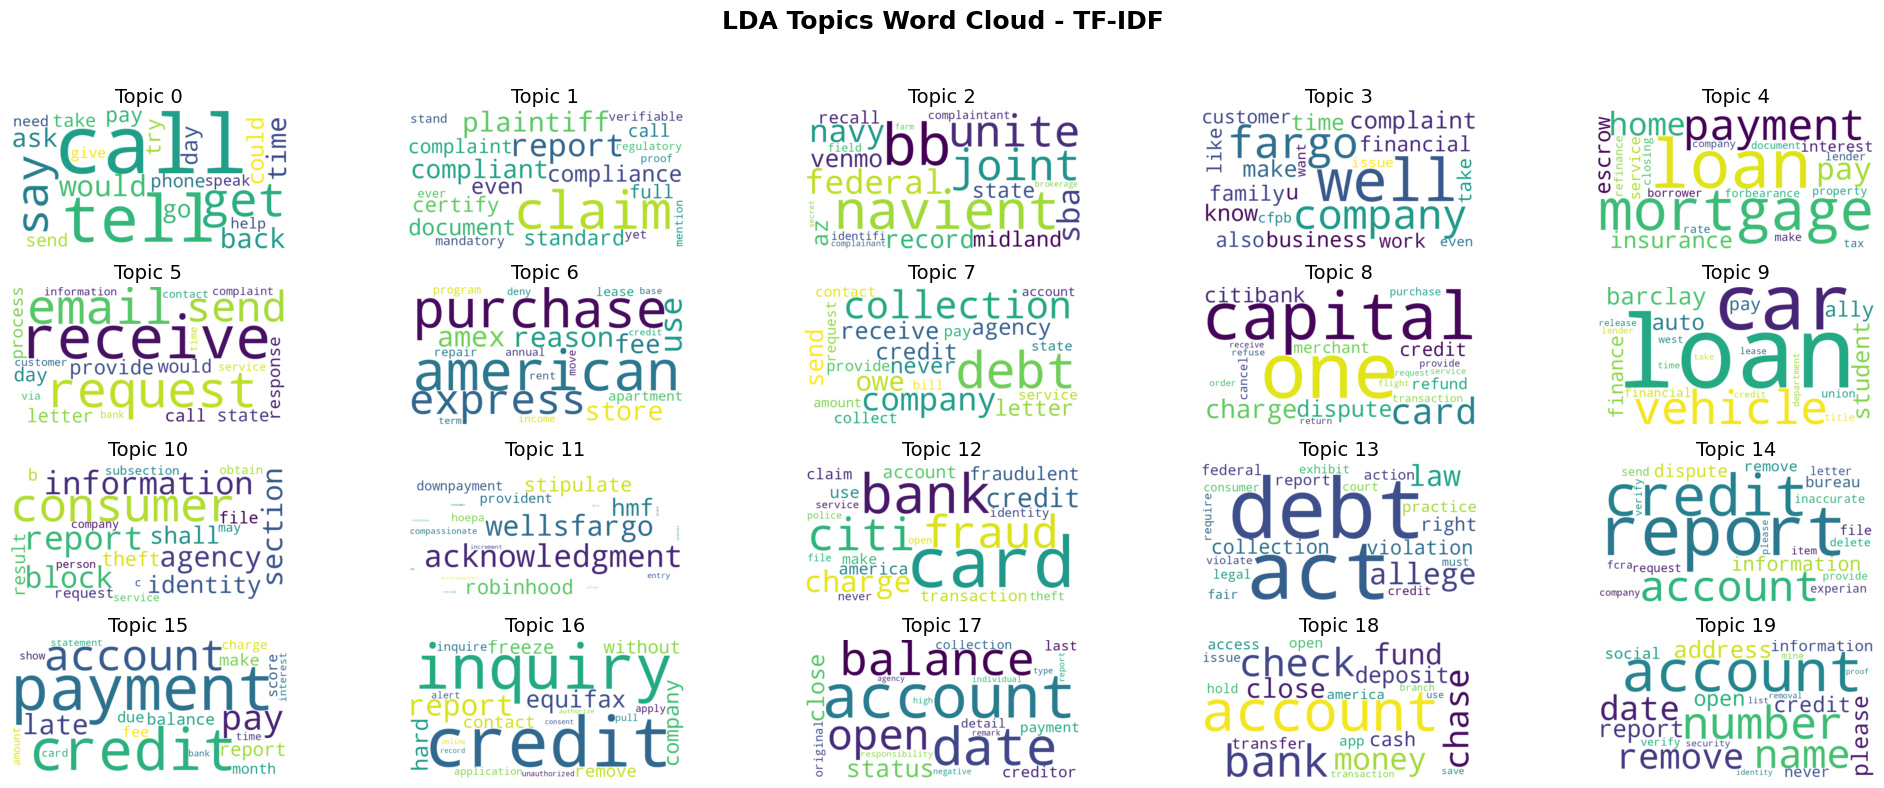

In [18]:
# Generate word clouds for LDA with TF-IDF
plot_wordclouds_grid(lda_tfidf, lda_tfidf.num_topics, tfidf_dictionary, "LDA Topics Word Cloud - TF-IDF")

The word clouds above illustrate the most important terms for each of the 20 topics identified by the LDA model using TF-IDF. The analysis aligns with the PyLDAvis interpretations and largely mirrors the findings from the BoW-based word clouds, confirming consistent themes in customer complaints related to credit reports, debt collection, fraud, loans, and financial disputes.

A key difference observed in the TF-IDF word clouds is the greater emphasis on unique and distinguishing terms within each topic compared to BoW. For example, legal and regulatory terms like "plaintiff," "exhibit," and "subsection" appear more prominently, indicating a sharper focus on compliance-related disputes. Additionally, TF-IDF assigns higher importance to specific financial entities (e.g., "Citibank," "Barclay") and industry-specific jargon ("FCRA," "Experian"), which were more diluted in BoW.

While both methods capture similar overarching topics, TF-IDF appears to refine the distinctions between them by reducing the influence of commonly occurring financial terms, making it more effective in identifying niche or specialized complaints.

### Evaluate Topic Distribution

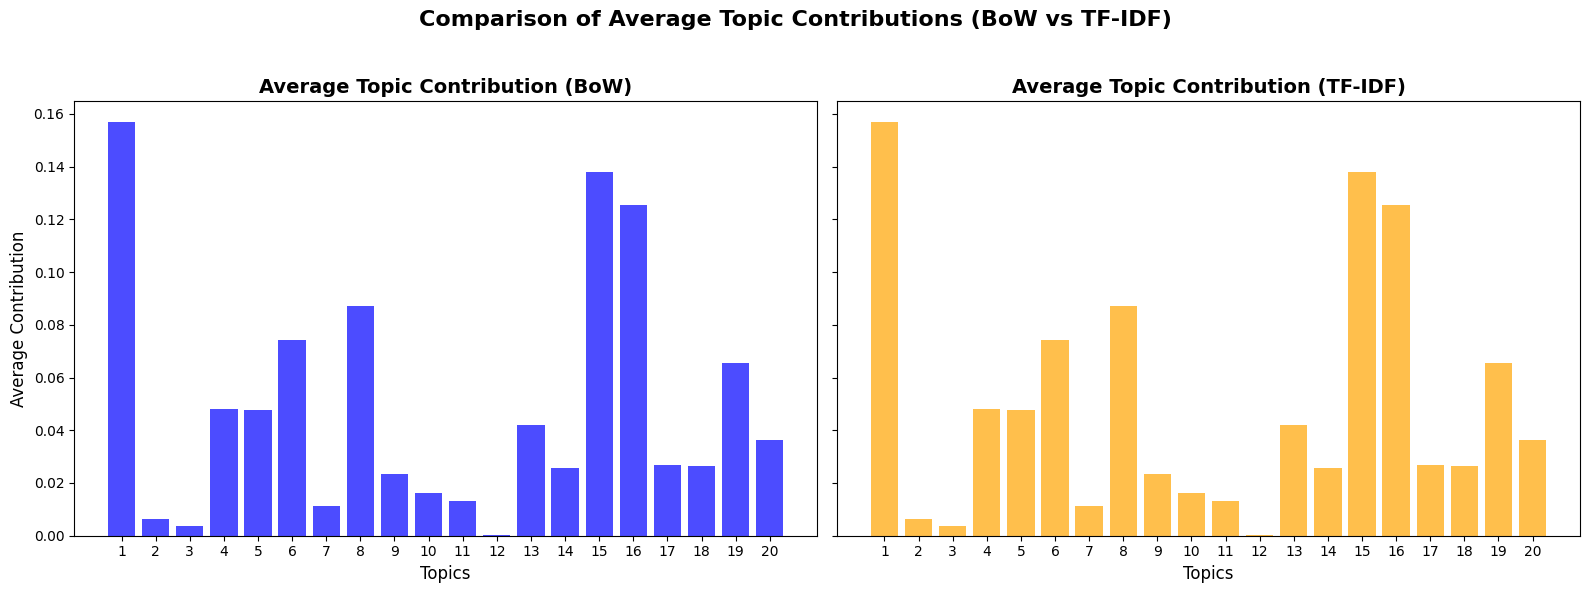

In [19]:
# Get topic distributions for each document
doc_topics_bow = [lda_bow.get_document_topics(doc) for doc in bow_corpus]
doc_topics_tfidf = [lda_tfidf.get_document_topics(doc) for doc in tfidf_corpus]

# Convert to matrix format
topic_matrix_bow = np.zeros((len(doc_topics_bow), lda_bow.num_topics))
for i, doc in enumerate(doc_topics_bow):
    for topic, prob in doc:
        topic_matrix_bow[i, topic] = prob

topic_matrix_tfidf = np.zeros((len(doc_topics_tfidf), lda_tfidf.num_topics))
for i, doc in enumerate(doc_topics_tfidf):
    for topic, prob in doc:
        topic_matrix_tfidf[i, topic] = prob

# Calculate average topic contributions
avg_topic_dist_bow = topic_matrix_bow.mean(axis=0)
avg_topic_dist_tfidf = topic_matrix_tfidf.mean(axis=0)

# Visualize BoW and TF-IDF topic distributions side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# BoW Topic Distribution
axes[0].bar(range(lda_bow.num_topics), avg_topic_dist_bow, alpha=0.7, color='blue')
axes[0].set_title("Average Topic Contribution (BoW)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Topics", fontsize=12)
axes[0].set_ylabel("Average Contribution", fontsize=12)
axes[0].set_xticks(range(lda_bow.num_topics))
axes[0].set_xticklabels(range(1, lda_bow.num_topics + 1))  # Convert to 1-based index

# TF-IDF Topic Distribution
axes[1].bar(range(lda_tfidf.num_topics), avg_topic_dist_tfidf, alpha=0.7, color='orange')
axes[1].set_title("Average Topic Contribution (TF-IDF)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Topics", fontsize=12)
axes[1].set_xticks(range(lda_tfidf.num_topics))
axes[1].set_xticklabels(range(1, lda_tfidf.num_topics + 1))  # Convert to 1-based index

# Add overall title
plt.suptitle("Comparison of Average Topic Contributions (BoW vs TF-IDF)", fontsize=16, fontweight='bold')

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

The graph above illustrates the average topic contributions for 20 topics in LDA models trained with BoW and TF-IDF representations.

**Similar Topic Importance Across Methods**

- The most dominant topics remain consistent between BoW and TF-IDF, indicating stability in topic modeling results.
- Topics 1, 16, and 15 show high contributions in both methods, suggesting they capture highly prevalent themes in the dataset.

**Variability in Lower-Contributing Topics**
  
- Some topics show lower average contributions (e.g., Topics 3, 10, and 11) in both models, suggesting they represent niche themes with limited presence in the dataset.
- TF-IDF tends to smooth out contributions across topics more evenly compared to BoW, which assigns more weight to certain dominant topics.

**Topic Weighting Differences**
  
- BoW has a stronger peak for Topic 1, meaning it dominates more compared to other topics.
- TF-IDF has a more distributed contribution, likely due to its ability to downweight common terms and highlight more informative words.

**Implication for Analysis**
  
- If the goal is to identify key recurring issues, BoW might be better for highlighting dominant topics.
- If the goal is to capture a broader range of issues, TF-IDF provides a more balanced distribution, giving weight to less frequent but important topics.

### Save Top Words

In [20]:
lda_bow_topics = {
    f"Topic {i}": [word for word, _ in lda_bow.show_topic(i, topn=10)]
    for i in range(lda_bow.num_topics)
}
with open("/Users/achshahrm/Library/Mobile Documents/com~apple~CloudDocs/Documents/IU International/Sem 05/Project Data Analysis/project_final/results/topics/lda_bow_topics.txt", "w") as f:
    for topic, words in lda_bow_topics.items():
        f.write(f"{topic}: {', '.join(words)}\n")

In [21]:
lda_tfidf_topics = {
    f"Topic {i}": [word for word, _ in lda_tfidf.show_topic(i, topn=10)]
    for i in range(lda_tfidf.num_topics)
}
with open("/Users/achshahrm/Library/Mobile Documents/com~apple~CloudDocs/Documents/IU International/Sem 05/Project Data Analysis/project_final/results/topics/lda_tfidf_topics.txt", "w") as f:
    for topic, words in lda_tfidf_topics.items():
        f.write(f"{topic}: {', '.join(words)}\n")

## **4. NMF using Scikit-Learn**

### With BoW Method

In [22]:
# Initialize NMF for BoW
nmf_bow = NMF(n_components=5, random_state=42, max_iter=500)
nmf_bow_topics = nmf_bow.fit_transform(bow_df)

# Extract top words for each topic
bow_topic_words = []
for topic_idx, topic in enumerate(nmf_bow.components_):
    top_words = [feature_names_bow[i] for i in topic.argsort()[:-11:-1]]  # Extract top 10 words
    bow_topic_words.append(top_words)
    print(f"Topic {topic_idx}: {top_words}")

Topic 0: ['account', 'date', 'balance', 'status', 'payment', 'open', 'creditor', 'close', 'ok', 'inquiry']
Topic 1: ['consumer', 'report', 'information', 'block', 'agency', 'section', 'identity', 'theft', 'shall', 'file']
Topic 2: ['credit', 'account', 'report', 'card', 'dispute', 'information', 'remove', 'charge', 'bank', 'number']
Topic 3: ['claim', 'debt', 'report', 'collection', 'compliance', 'plaintiff', 'allege', 'document', 'compliant', 'requisite']
Topic 4: ['payment', 'loan', 'make', 'time', 'pay', 'receive', 'check', 'issue', 'bank', 'tell']


The topic modeling results from NMF using Bag of Words (BoW) reveal distinct themes related to financial issues, credit reporting, and account management. The extracted topics align with common themes in financial consumer complaints, similar to what was observed in LDA results. Below are the key topic interpretations:

**Topic Interpretations:**

- Topic 0: Focuses on account status and balance management, with words like "account, date, balance, status, payment, open, creditor, close." This topic is likely about financial account updates, payment statuses, and credit management.

- Topic 1: Covers consumer credit reporting and identity protection, containing words like "consumer, report, information, block, agency, section, identity, theft, file." This topic suggests concerns about credit bureau reports, identity theft, and data security.

- Topic 2: Relates to credit disputes and fraud prevention, with terms like "credit, account, report, card, dispute, information, remove, charge, bank, number." This topic highlights credit-related issues, fraudulent charges, and disputes over incorrect reporting.

- Topic 3: Discusses debt collection and legal compliance, featuring words like "claim, debt, report, collection, compliance, plaintiff, allege, document, compliant, requisite." This topic suggests complaints about aggressive debt collection practices and legal claims.

- Topic 4: Focuses on loan payments and transaction issues, with words like "payment, loan, make, time, pay, receive, check, issue, bank, tell." This topic revolves around loan payments, check processing, and general banking concerns.

**Comparison with LDA:**

- The NMF topics using BoW are consistent with the LDA model results, covering similar financial issues such as credit reports, debt collection, payments, and fraud.

- NMF appears to provide sharper topic separation, grouping legal and compliance terms into a separate topic (Topic 3), which was more blended in LDA.

- Unlike LDA, which sometimes had topic overlap, NMF BoW shows clearer topic boundaries, making interpretation easier.

### With TF-IDF Method

In [23]:
# Initialize NMF for TF-IDF
nmf_tfidf = NMF(n_components=10, random_state=42, max_iter=500)
nmf_tfidf_topics = nmf_tfidf.fit_transform(tfidf_df)

# Extract top words for each topic
tfidf_topic_words = []
for topic_idx, topic in enumerate(nmf_tfidf.components_):
    top_words = [feature_names_tfidf[i] for i in topic.argsort()[:-11:-1]]  # Extract top 10 words
    tfidf_topic_words.append(top_words)
    print(f"Topic {topic_idx}: {top_words}")

Topic 0: ['report', 'credit', 'remove', 'bureau', 'inaccurate', 'score', 'information', 'agency', 'experian', 'delete']
Topic 1: ['loan', 'mortgage', 'pay', 'company', 'tell', 'home', 'time', 'say', 'month', 'ask']
Topic 2: ['debt', 'collection', 'owe', 'company', 'collect', 'agency', 'collector', 'pay', 'allege', 'validation']
Topic 3: ['payment', 'late', 'make', 'pay', 'month', 'fee', 'day', 'date', 'balance', 'miss']
Topic 4: ['card', 'charge', 'credit', 'capital', 'fee', 'use', 'citi', 'purchase', 'pay', 'balance']
Topic 5: ['account', 'open', 'close', 'balance', 'date', 'status', 'creditor', 'remove', 'number', 'collection']
Topic 6: ['letter', 'dispute', 'send', 'request', 'information', 'provide', 'verify', 'receive', 'consumer', 'proof']
Topic 7: ['bank', 'check', 'america', 'money', 'chase', 'fund', 'deposit', 'tell', 'transfer', 'day']
Topic 8: ['identity', 'theft', 'information', 'victim', 'fraudulent', 'consumer', 'block', 'ftc', 'report', 'file']
Topic 9: ['inquiry', 'hard

The NMF topics using TF-IDF reveal distinct financial concerns, closely aligning with both LDA and NMF BoW results but showing sharper differentiation between fraud, credit disputes, and banking transactions. Below are the key topic interpretations:

**Topic Interpretations:**

- Topic 0: Focuses on credit report corrections and disputes, with words like "report, credit, remove, bureau, inaccurate, score, information, agency, experian, delete." This topic relates to inaccuracies in credit reports and requests for data removal.

- Topic 1: Covers mortgage and loan servicing, containing words like "loan, mortgage, pay, company, home, time, month." This topic suggests consumer complaints about loan payments, mortgage handling, and company responses.

- Topic 2: Discusses debt collection practices, featuring words like "debt, collection, owe, company, collect, agency, collector, pay, allege, validation." This topic pertains to aggressive debt collection efforts and disputes.

- Topic 3: Focuses on payment delays and fees, with words like "payment, late, make, pay, month, fee, balance, miss." This topic captures concerns about late fees, missed payments, and overdue balances.

- Topic 4: Relates to credit card charges and disputes, with words like "card, charge, credit, capital, fee, use, citi, purchase, pay, balance." This topic highlights credit card billing issues and unauthorized charges.

- Topic 5: Concerns account closures and status changes, featuring words like "account, open, close, balance, date, status, creditor, remove, number, collection." This topic is about account modifications and creditor reporting.

- Topic 6: Covers consumer dispute resolution, with words like "letter, dispute, send, request, information, provide, verify, receive, consumer, proof." This topic deals with the process of disputing financial issues and submitting verification.

- Topic 7: Discusses bank transactions and fund transfers, with words like "bank, check, america, money, chase, fund, deposit, transfer, tell, day." This topic relates to issues with deposits, fund availability, and banking operations.

- Topic 8: Focuses on identity theft and fraud, featuring words like "identity, theft, information, victim, fraudulent, consumer, block, ftc, report, file." This topic highlights concerns about fraudulent activity and consumer protection.

- Topic 9: Covers credit inquiries and unauthorized checks, with words like "inquiry, hard, credit, authorize, unauthorized, remove, date, add, removal, inquire." This topic is about credit checks, unauthorized inquiries, and security concerns.

**Comparison with NMF BoW:**

- TF-IDF clearly separates identity theft (Topic 8), credit inquiries (Topic 9), and credit report disputes (Topic 0), while BoW had more overlap between these concerns.

- TF-IDF places greater emphasis on unauthorized inquiries and identity theft, making fraud-related issues more distinct than in BoW.

- BoW had broader categories, TF-IDF is more specific: Topics like debt collection, account management, and payments were blended in BoW, whereas TF-IDF isolates charge disputes (Topic 4), payment issues (Topic 3), and account closures (Topic 5).

TF-IDF generally provides more focused and interpretable topics, making it a better choice for understanding nuanced financial complaints.

### Evaluate Topic Coherence

In [24]:
# Function to compute coherence for NMF topics
def compute_nmf_coherence(nmf_model, feature_names, texts, dictionary, coherence='c_v'):
    # Extract top words for each topic
    topics = []
    for topic_idx in range(nmf_model.n_components):
        top_words = [feature_names[i] for i in nmf_model.components_[topic_idx].argsort()[:-11:-1]]
        topics.append(top_words)
    
    # Use Gensim's CoherenceModel
    coherence_model = CoherenceModel(topics=topics, texts=texts, dictionary=dictionary, coherence=coherence)
    coherence_score = coherence_model.get_coherence()
    
    return coherence_score

# Tokenized texts from preprocessed data
tokenized_texts = data_preprocessed['complaints_text'].str.split()

# Create a Gensim dictionary
dictionary = Dictionary(tokenized_texts)

# Compute coherence for NMF with BoW
coherence_nmf_bow = compute_nmf_coherence(nmf_bow, feature_names_bow, tokenized_texts, dictionary)
print(f"NMF with BoW Coherence Score: {coherence_nmf_bow:.4f}")

# Compute coherence for NMF with TF-IDF
coherence_nmf_tfidf = compute_nmf_coherence(nmf_tfidf, feature_names_tfidf, tokenized_texts, dictionary)
print(f"NMF with TF-IDF Coherence Score: {coherence_nmf_tfidf:.4f}")

NMF with BoW Coherence Score: 0.6049
NMF with TF-IDF Coherence Score: 0.5596


### Evaluate Word Cloud Visualization

In [30]:
# Word Cloud for NMF topics
def plot_nmf_wordclouds_grid(nmf_model, num_topics, feature_names, title):
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    axes = axes.flatten()
    
    for topic_idx, ax in enumerate(axes[:num_topics]):
        wordcloud = WordCloud(width=800, height=400, background_color='white')
        topic_terms = {feature_names[i]: nmf_model.components_[topic_idx][i] for i in nmf_model.components_[topic_idx].argsort()[:-21:-1]}
        wordcloud.generate_from_frequencies(topic_terms)
        ax.imshow(wordcloud, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f"Topic {topic_idx}", fontsize=14)
    
    for ax in axes[num_topics:]:
        ax.axis('off')
    
    plt.suptitle(title, fontsize=18, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

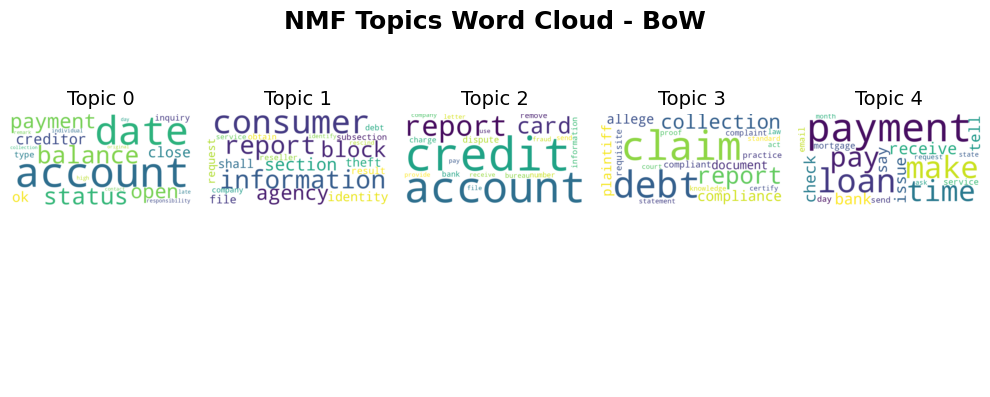

In [31]:
# Generate word clouds for NMF with BoW
plot_nmf_wordclouds_grid(nmf_bow, nmf_bow.n_components, feature_names_bow, "NMF Topics Word Cloud - BoW")

The topic interpretations from the NMF using Bag of Words (BoW) word cloud remain consistent with the insights derived from the top words. The themes revolve around account management, credit reporting, debt collection, loan payments, and compliance-related disputes. However, from the word cloud, we observe additional nuances that provide a deeper understanding of how these topics are structured.

One key observation is the prominence of "compliance," "plaintiff," and "allege" in Topic 3, reinforcing the idea that this topic is heavily tied to legal disputes and regulatory challenges. This suggests that a significant number of complaints involve not just debt collection but also legal action against financial institutions or collectors. The presence of words like "document" and "requisite" further implies a paperwork-heavy process, possibly related to legal filings or regulatory documentation.

Another interesting insight is in Topic 1, where the word "block" appears strongly. This suggests that many complaints might involve credit freezes or identity protection measures, indicating growing concerns over data security breaches, fraudulent activities, or issues with credit bureaus preventing consumers from accessing their own credit information. While the top words hinted at identity theft and reporting concerns, the word cloud provides a clearer emphasis on active security actions, such as placing blocks or restrictions on credit accounts.

Additionally, Topic 4 highlights terms like "receive" and "check", which may point to issues with loan disbursement, delayed payments, or check-processing errors. The presence of "tell" in the word cloud could indicate a strong customer service component, where consumers frequently have to call or follow up on these financial transactions.

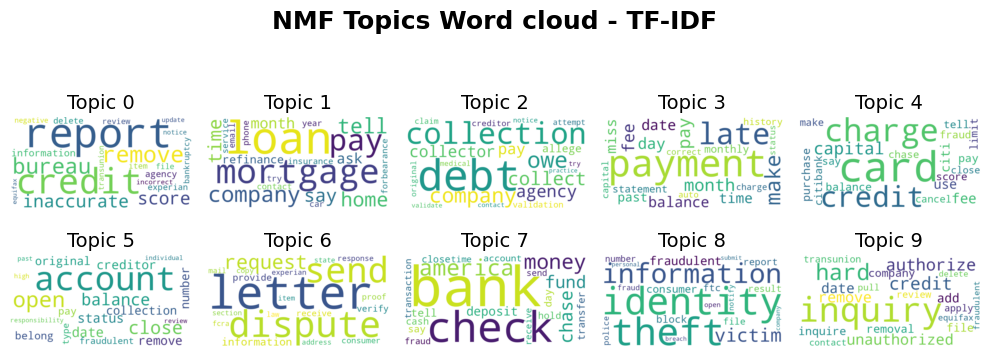

In [32]:
# Generate word clouds for NMF with TF-IDF
plot_nmf_wordclouds_grid(nmf_tfidf, nmf_tfidf.n_components, feature_names_tfidf, "NMF Topics Word cloud - TF-IDF")

The NMF using TF-IDF word cloud aligns closely with the BoW word cloud, with similar topic interpretations centered around credit reports, loan payments, debt collection, identity theft, and credit card disputes. However, TF-IDF introduces some distinct nuances by emphasizing less frequent but more informative terms, leading to sharper topic differentiation.

One key difference observed in Topic 0 (credit reports and disputes) is the stronger presence of terms like "remove," "bureau," and "inaccurate", reinforcing that many complaints focus on correcting errors in credit reports rather than just general reporting concerns. Compared to BoW, which highlights broad financial account management, the TF-IDF representation puts greater emphasis on disputed credit items and agency-related issues.

Similarly, in Topic 1 (loans and mortgage payments), TF-IDF enhances the role of specific financial challenges such as "refinance," "insurance," and "forbearance", suggesting that complaints are often tied to loan modifications, payment delays, and mortgage-related difficulties. This topic is slightly broader than its BoW counterpart, capturing a wider range of financial difficulties beyond just payments.

For Topic 3 (payment issues and balances), the TF-IDF word cloud emphasizes "miss," "past," and "statement", indicating a stronger concern about payment histories, missing payments, and potential account delinquencies. In contrast, the BoW version of this topic was more transaction-focused with words like "receive" and "check."

Another noticeable distinction is in Topic 6 (disputes and verification requests). The TF-IDF representation highlights "letter," "send," and "response," suggesting a greater focus on formal complaint processes, written disputes, and document verification, whereas the BoW representation was broader, capturing more generic information requests.

Lastly, Topic 9 (credit inquiries and fraud prevention) shows a stronger emphasis on "unauthorized," "hard," and "removal" in the TF-IDF version. This highlights a greater concern about unauthorized hard inquiries on credit reports, whereas BoW had a more balanced focus between general inquiries and fraud-related issues.

### Evaluate Topic Distribution

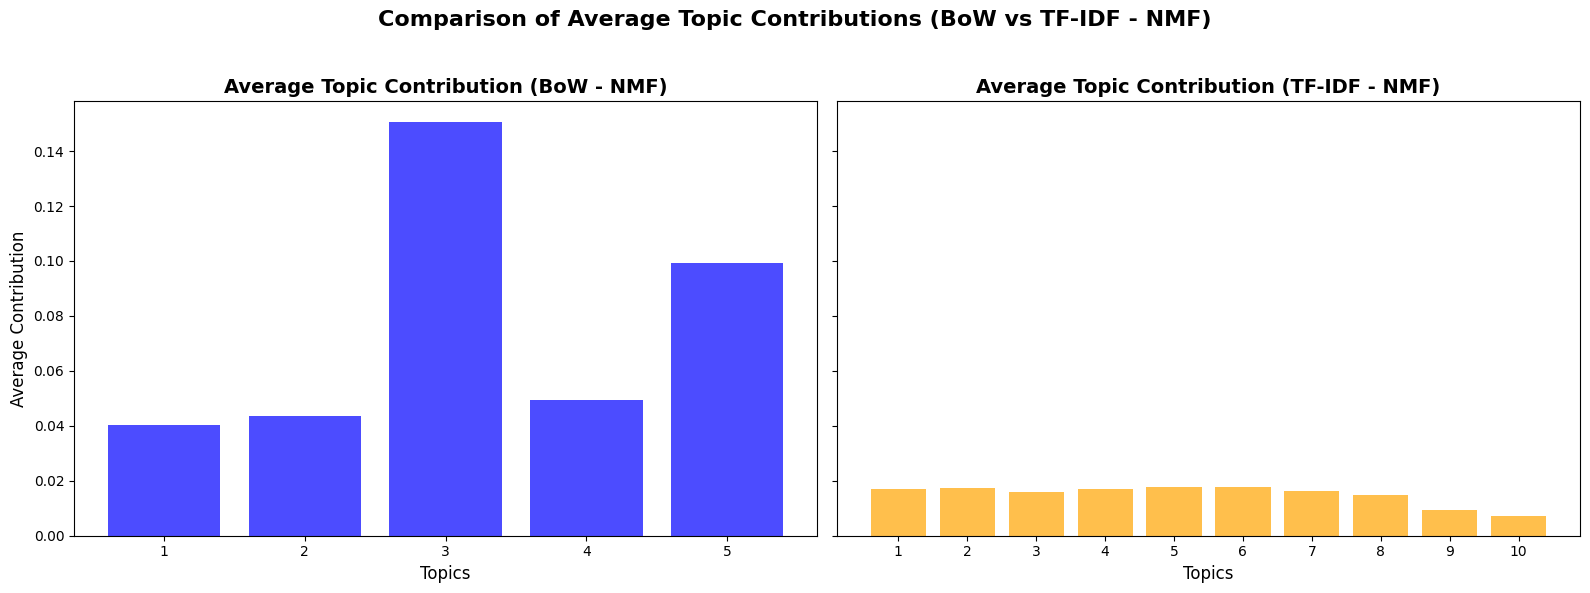

In [33]:
# Compute the average topic contributions for BoW and TF-IDF
avg_topic_dist_bow_nmf = nmf_bow_topics.mean(axis=0)
avg_topic_dist_tfidf_nmf = nmf_tfidf_topics.mean(axis=0)

# Plot side-by-side bar charts for BoW and TF-IDF
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# BoW Topic Distribution
axes[0].bar(range(nmf_bow.n_components), avg_topic_dist_bow_nmf, color='blue', alpha=0.7)
axes[0].set_title("Average Topic Contribution (BoW - NMF)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Topics", fontsize=12)
axes[0].set_ylabel("Average Contribution", fontsize=12)
axes[0].set_xticks(range(nmf_bow.n_components))
axes[0].set_xticklabels(range(1, nmf_bow.n_components + 1))  # Convert to 1-based index

# TF-IDF Topic Distribution
axes[1].bar(range(nmf_tfidf.n_components), avg_topic_dist_tfidf_nmf, color='orange', alpha=0.7)
axes[1].set_title("Average Topic Contribution (TF-IDF - NMF)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Topics", fontsize=12)
axes[1].set_xticks(range(nmf_tfidf.n_components))
axes[1].set_xticklabels(range(1, nmf_tfidf.n_components + 1))  # Convert to 1-based index

# Add overall title
plt.suptitle("Comparison of Average Topic Contributions (BoW vs TF-IDF - NMF)", fontsize=16, fontweight='bold')

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Display the plot
plt.show()

The graph above illustrates the average topic contributions for the NMF model trained with BoW and TF-IDF representations.

**Differences in Topic Distribution**

- The BoW representation shows a clear dominance of certain topics, particularly Topic 3, which has the highest contribution. This indicates that a few topics account for a large portion of the dataset.
- In contrast, TF-IDF distributes topic contributions more evenly, but at a much lower scale. No single topic stands out significantly, which suggests that TF-IDF captures more nuanced but lower-weighted topics across the dataset.

**Variability in Topic Contributions**

- BoW exhibits a stronger peak structure, meaning certain topics are far more dominant, while others contribute minimally. This suggests that BoW focuses on frequently occurring terms, leading to a concentrated representation of major issues.
- TF-IDF assigns smaller weights to all topics, resulting in a more even but lower overall topic distribution. This is expected, as TF-IDF downweights frequent words and enhances less common but informative terms.

**Topic Importance and Stability**

- The major themes captured by BoW are heavily concentrated in a few topics, making it useful for identifying the most prevalent concerns.
- TF-IDF, on the other hand, provides a more balanced perspective, capturing subtler patterns in the data.

**Implications for Analysis**

- BoW-NMF is better suited for highlighting dominant recurring issues, as certain topics contribute much more strongly to the overall dataset.
- TF-IDF-NMF is ideal for identifying diverse and less frequent themes, as it smooths out topic distribution, giving lower importance to overly common words.ent terms.

### Save Top Words

In [36]:
nmf_bow_topics = {
    f"Topic {i}": [feature_names_bow[j] for j in nmf_bow.components_[i].argsort()[:-11:-1]]
    for i in range(nmf_bow.n_components)
}
with open("/Users/achshahrm/Library/Mobile Documents/com~apple~CloudDocs/Documents/IU International/Sem 05/Project Data Analysis/project_final/results/topics/nmf_bow_topics.txt", "w") as f:
    for topic, words in nmf_bow_topics.items():
        f.write(f"{topic}: {', '.join(words)}\n")

In [37]:
nmf_tfidf_topics = {
    f"Topic {i}": [feature_names_tfidf[j] for j in nmf_tfidf.components_[i].argsort()[:-11:-1]]
    for i in range(nmf_tfidf.n_components)
}
with open("/Users/achshahrm/Library/Mobile Documents/com~apple~CloudDocs/Documents/IU International/Sem 05/Project Data Analysis/project_final/results/topics/nmf_tfidf_topics.txt", "w") as f:
    for topic, words in nmf_tfidf_topics.items():
        f.write(f"{topic}: {', '.join(words)}\n")

## **5. BERTopic using bertopic**

In [38]:
# Extract the complaints_text column as input for BERTopic
documents = data_preprocessed['complaints_text'].sample(n=5000, random_state=42).tolist()

# Load a lightweight embedding model
embedding_model = SentenceTransformer("paraphrase-MiniLM-L3-v2")

# Initialize PCA for dimensionality reduction
pca_model = PCA(n_components=50)

# Initialize BERTopic with automatic topic optimization
topic_model = BERTopic(umap_model=pca_model, embedding_model=embedding_model, nr_topics="auto", verbose=True)

# Fit BERTopic model
topics, probs = topic_model.fit_transform(documents)

2025-02-28 20:00:00,918 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

2025-02-28 20:00:26,354 - BERTopic - Embedding - Completed ✓
2025-02-28 20:00:26,355 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-02-28 20:00:26,394 - BERTopic - Dimensionality - Completed ✓
2025-02-28 20:00:26,398 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-02-28 20:00:29,316 - BERTopic - Cluster - Completed ✓
2025-02-28 20:00:29,316 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-02-28 20:00:29,562 - BERTopic - Representation - Completed ✓
2025-02-28 20:00:29,563 - BERTopic - Topic reduction - Reducing number of topics
2025-02-28 20:00:29,781 - BERTopic - Topic reduction - Reduced number of topics from 10 to 10


### Evaluate Topic Coherence

In [39]:
# Tokenized documents (from preprocessed data)
tokenized_documents = [doc.split() for doc in documents]

# Create a Gensim dictionary
dictionary = Dictionary(tokenized_documents)

# Extract topics from BERTopic (excluding topic -1 for outliers)
topics = topic_model.get_topics()
formatted_topics = []

for topic_id in topics:
    if topic_id != -1:  # Ignore outlier topic
        formatted_topics.append([word[0] for word in topics[topic_id]])

# Compute coherence score
coherence_model = CoherenceModel(
    topics=formatted_topics, texts=tokenized_documents, dictionary=dictionary, coherence='c_v'
)
coherence_bert = coherence_model.get_coherence()

print(f"BERTopic Coherence Score: {coherence_bert:.4f}")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

BERTopic Coherence Score: 0.5295


### Visualize Topic Distributions

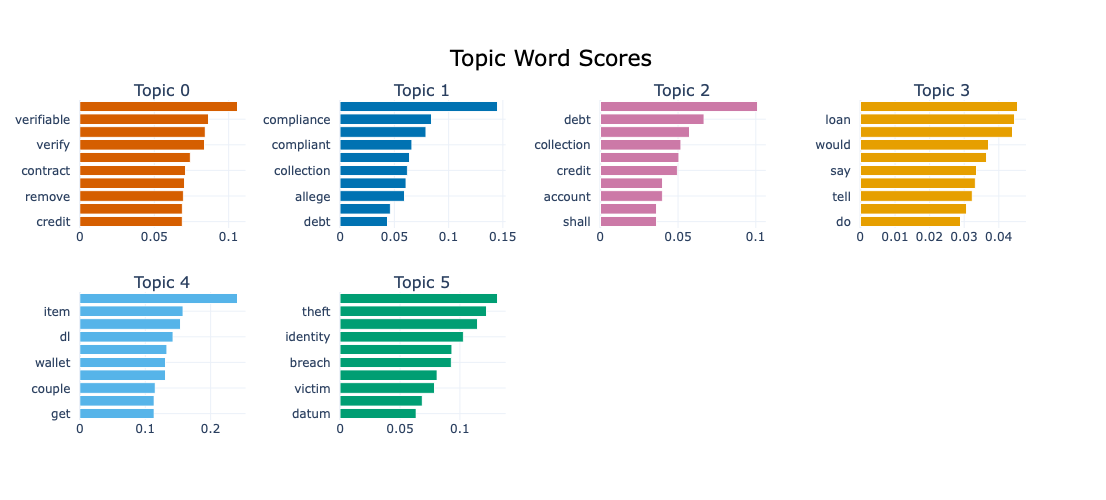

In [41]:
# Generate the bar chart for all topics
fig = topic_model.visualize_barchart(top_n_topics=None, n_words=10)

# Show the plot
fig.show()

The bar chart visualization above represents the most significant words associated with each topic identified by the BERTopic model. Each topic is characterized by five most representative words, with the horizontal bars indicating their importance within that topic.

**Key Insights from the Chart:**

- Topic 0 - Identity Verification & Credit Removal:
The presence of words like "verifiable," "verify," "contract," "remove," and "credit" suggests this topic is about identity verification, contract validation, and credit account removals. This may relate to credit report disputes, where consumers attempt to validate or remove incorrect information from their financial records.

- Topic 1 - Compliance & Debt Collection Issues:
Words like "compliance," "compliant," "collection," "allege," and "debt" indicate regulatory compliance and debt collection issues. This topic likely represents legal and procedural concerns in debt collection, where individuals might be disputing debt claims or challenging aggressive collection practices.

- Topic 2 - Debt & Credit Management:
The terms "debt," "collection," "credit," "account," and "shall" point toward credit management and debt handling. This could reflect consumer concerns about debt repayment, loan obligations, and creditor demands.

- Topic 3 - Loan & Financial Communication:
The words "loan," "would," "say," "tell," and "do" suggest a focus on conversations around loans and financial discussions. This topic may represent consumer negotiations or disputes related to loans, interest rates, and payment terms.

- Topic 4 - Digital Transactions & Wallet Issues:
Terms like "item," "dl," "wallet," "couple," and "get" point toward digital transactions, wallets, and potential verification issues. The presence of "wallet" suggests disputes regarding digital banking, lost funds, or unauthorized transactions.

- Topic 5 - Identity Theft & Fraud Prevention:
Words like "theft," "identity," "breach," "victim," and "datum" indicate concerns about data breaches, identity theft, and fraud. This topic highlights consumer worries about unauthorized access, personal data security, and fraud prevention efforts.

**Overall Observations:**

- The dominant themes in the topics align with financial security, debt collection, credit reporting, and loan management.

- Fraud and identity theft appear as a major concern, reflecting real-world issues where consumers deal with stolen identities and unauthorized financial activities.

- The variation in word importance across topics indicates that BERTopic effectively separates discussions into distinct financial themes.

- Compared to traditional models like LDA and NMF, BERTopic seems to capture more nuanced and conversational elements, such as communication terms ("say," "tell," "would") in loan-related topics..

### Visualize Topic Hierarchies

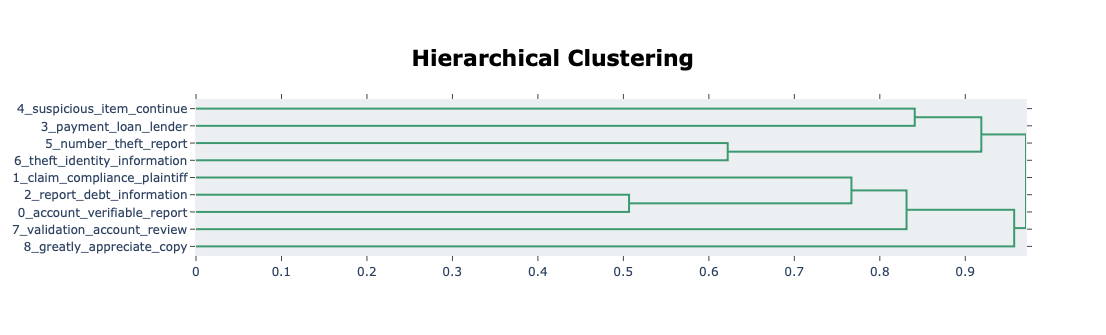

In [42]:
topic_model.visualize_hierarchy()

The hierarchical clustering dendrogram, groups similar text items based on their semantic similarity.

**Closely related topics:**

- "account_verifiable_report" and "validation_account_review" are clustered together, suggesting strong similarity in themes related to account verification.
- "theft_identity_information" and "number_theft_report" are also close, indicating a focus on fraud or theft-related issues.

**Wider clusters:**

- "payment_loan_lender" and "suspicious_item_continue" form a broader cluster, potentially indicating financial risk or fraud concerns.
- "claim_compliance_plaintiff" is linked to "report_debt_information," which may suggest legal and financial document similarities.

**Overall structure:**

The clustering reveals logical groupings of terms related to fraud, financial verification, and legal claims, indicating that the text data follows a pattern of financial and security-related concerns.

### Visualize Inter-Topic Distances

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


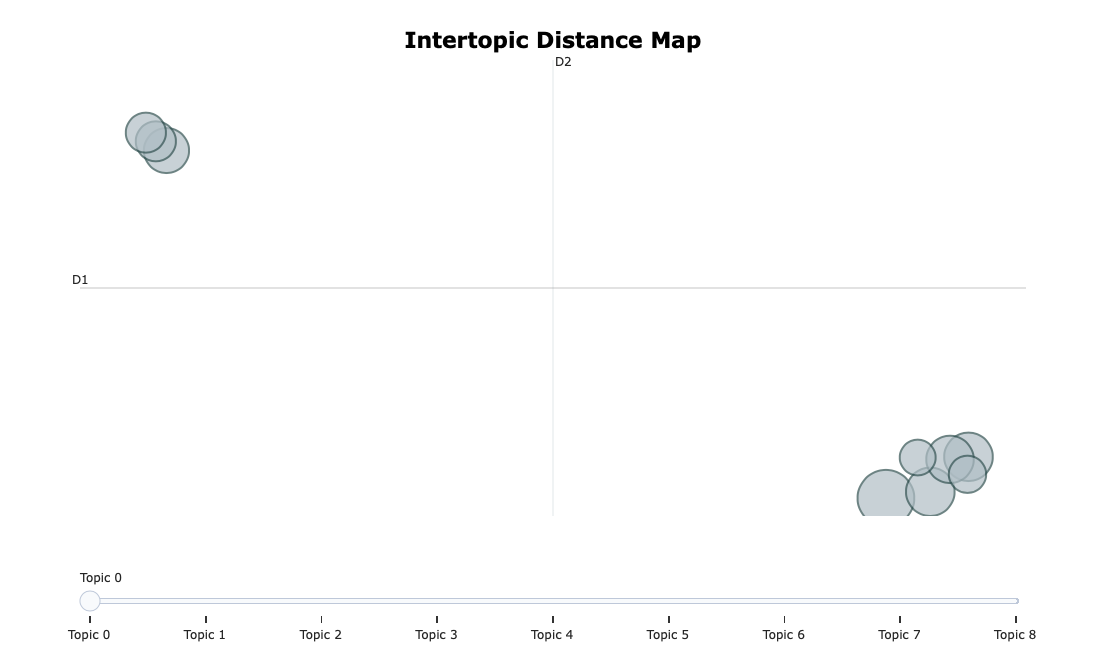

In [43]:
topic_model.visualize_topics()

The inter-topic distance maps show how the extracted topics are distributed in a two-dimensional space.

- Topic Separation: The visualization suggests that there are two distinct topic clusters. One cluster appears in the bottom-right quadrant, indicating that multiple topics share similarities. The other, more isolated cluster in the top-left quadrant suggests topics that are more unique or independent.

- Overlap & Distinctiveness: Topics that appear close together in the bottom-right suggest overlapping themes or discussions with shared keywords. The topics in the top-left are further apart, indicating more distinct themes.

- Topic Diversity: The relatively tight clustering of most topics suggests that many discussions are interconnected, potentially requiring further refinement to achieve more distinct separation.

### Additional Data For Evaluation

In [44]:
print(topic_model.get_topic_info())

   Topic  Count                                    Name  \
0     -1   4831        -1_account_credit_report_payment   
1      0     30      0_account_verifiable_report_verify   
2      1     22  1_claim_compliance_plaintiff_compliant   
3      2     22    2_report_debt_information_collection   
4      3     21             3_payment_loan_lender_would   
5      4     19           4_suspicious_item_continue_dl   
6      5     15          5_number_theft_report_identity   
7      6     15     6_theft_identity_information_submit   
8      7     13      7_validation_account_review_belong   
9      8     12  8_greatly_appreciate_copy_respectfully   

                                      Representation  \
0  [account, credit, report, payment, call, pay, ...   
1  [account, verifiable, report, verify, proof, c...   
2  [claim, compliance, plaintiff, compliant, requ...   
3  [report, debt, information, collection, person...   
4  [payment, loan, lender, would, call, say, ask,...   
5  [suspicious

### Save Top Words

In [45]:
bertopic_topics = topic_model.get_topics()
with open("/Users/achshahrm/Library/Mobile Documents/com~apple~CloudDocs/Documents/IU International/Sem 05/Project Data Analysis/project/results/topics/bertopic_topics.txt", "w") as f:
    for topic_id, words in bertopic_topics.items():
        word_list = [word[0] for word in words]  # Extract just the words
        f.write(f"Topic {topic_id}: {', '.join(word_list)}\n")

## **6. Overall Evaluation**

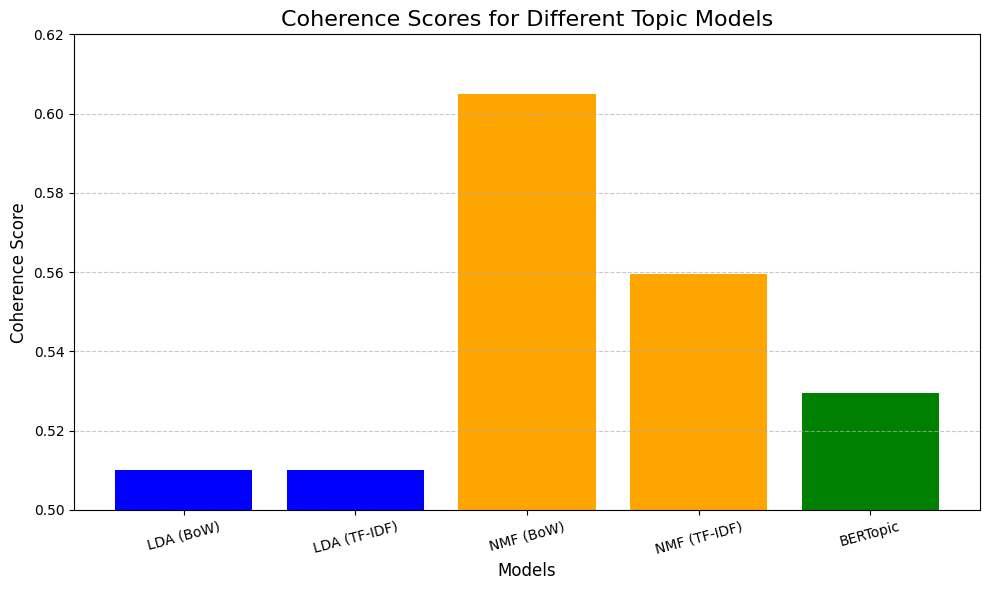

In [46]:
# Coherence scores for different models
models = ["LDA (BoW)", "LDA (TF-IDF)", "NMF (BoW)", "NMF (TF-IDF)", "BERTopic"]
scores = [coherence_lda_bow, coherence_lda_tfidf, coherence_nmf_bow, coherence_nmf_tfidf, coherence_bert]

# Create the bar plot
plt.figure(figsize=(10, 6))
plt.bar(models, scores, color=['blue', 'blue', 'orange', 'orange', 'green'])
plt.title("Coherence Scores for Different Topic Models", fontsize=16)
plt.ylabel("Coherence Score", fontsize=12)
plt.xlabel("Models", fontsize=12)
plt.ylim(0.5, 0.62)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=10, rotation=15)

# Display the plot
plt.tight_layout()
plt.show()

The bar graph illustrates the coherence scores of different topic modeling techniques, including LDA (BoW and TF-IDF), NMF (BoW and TF-IDF), and BERTopic.

- **NMF (BoW) Achieves the Highest Coherence Score** – This model significantly outperforms all others, indicating that it produces more semantically consistent and interpretable topics. The high coherence suggests that topics generated using NMF with Bag-of-Words are more cohesive and meaningful.

- **NMF (TF-IDF) Also Performs Well** – Although slightly lower than NMF (BoW), NMF with TF-IDF still maintains a strong coherence score. This suggests that TF-IDF is effective at capturing relevant topic-specific words while maintaining topic coherence.

- **LDA (BoW and TF-IDF) Show the Lowest Coherence Scores** – Both LDA models perform similarly and have the lowest coherence scores in the graph. This suggests that LDA struggles to produce highly distinct and interpretable topics, possibly due to topic overlap or the nature of the dataset.

- **BERTopic Falls Between LDA and NMF** – While BERTopic performs better than LDA, it still lags behind NMF. This may be because BERTopic clusters documents based on embeddings, which can sometimes result in less clearly defined topics compared to matrix factorization techniques like NMF.

## **7. Conclusion**

This project explored topic modeling on consumer complaint data using multiple algorithms—LDA, NMF, and BERTopic—along with Bag-of-Words (BoW) and TF-IDF vectorization techniques. The results of these models were evaluated using coherence scores and visualizations, leading to the following insights:

NMF (BoW) emerged as the most effective model in terms of topic coherence, indicating that it produces well-defined and interpretable topics. This can be attributed to NMF’s ability to optimally decompose term-document matrices, resulting in clearer topic-word distributions. The Bag-of-Words approach appears to better capture dominant patterns in the dataset compared to TF-IDF. While BERTopic showed moderate coherence, it remains valuable for capturing nuanced semantic relationships, particularly in cases where contextual meaning is essential.

This project successfully identified key topics in consumer complaint data, offering a scalable methodology for understanding customer feedback. The results can guide businesses in addressing recurring issues and enhancing customer experience by leveraging the most effective topic modeling approaches.